In [77]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu126
GPU available: True
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU


FLOW=>
Image file → PIL Image → Tensor → Model

In [79]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# transform: convert images to tensors and normalize to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# download and load MNIST
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

print("Dataset size:", len(train_dataset))
print("Batch shape:", next(iter(train_loader))[0].shape)



Dataset size: 60000
Batch shape: torch.Size([128, 1, 28, 28])


FLOW =>
Batch → Pick 10 images → Remove channel dim → Plot → Add labels → Show

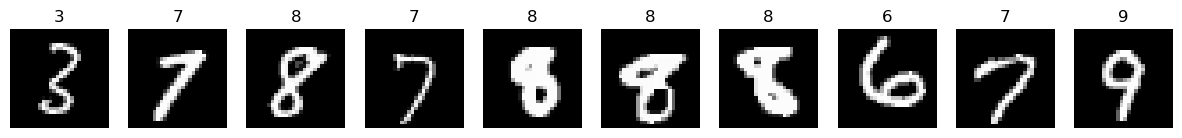

In [81]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(str(labels[i].item()))
    ax.axis('off')
plt.show()

In [103]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Flatten(),           # [128, 1, 28, 28] → [128, 784](image into vector)
            nn.Linear(784, 512),    # 784 input pixels → 400 hidden units
            nn.ReLU(),               # it is an activation function 
            nn.Linear(512, 256),
            nn.ReLU()
        )
        
        self.mu = nn.Linear(256, latent_dim)      # outputs mean
        self.log_var = nn.Linear(256, latent_dim) # outputs log variance (not σ directly,but log(σ^2) => more stable)
    
    def forward(self, x):
        h = self.net(x)
        return self.mu(h), self.log_var(h)  # returns both μ and log(σ²)

# test it
encoder = Encoder(latent_dim=16)  # we compress each image down to 16 numbers
x, _ = next(iter(train_loader))
mu, log_var = encoder(x)

print("Input shape:", x.shape)         # [128, 1, 28, 28]
print("Mu shape:", mu.shape)           # [128, 16]
print("Log var shape:", log_var.shape) # [128, 16]

Input shape: torch.Size([128, 1, 28, 28])
Mu shape: torch.Size([128, 16])
Log var shape: torch.Size([128, 16])


In [105]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),  # 16 numbers → 400 hidden units
            nn.ReLU(),
            nn.Linear(256, 512),         # 400 → 784 pixels
            nn.ReLU(),
            nn.Linear(512, 784),         # 400 → 784 pixels
            nn.Tanh()                    # output range [-1,1] to match our normalized input
        )
    
    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)  # reshape back to image format

# test it
decoder = Decoder(latent_dim=16)
z = torch.randn(128, 16)  # random latent vector
out = decoder(z)

print("Input z shape:", z.shape)   # [128, 16]
print("Output shape:", out.shape)  # [128, 1, 28, 28]

Input z shape: torch.Size([128, 16])
Output shape: torch.Size([128, 1, 28, 28])


In [107]:
def reparameterize(mu, log_var):
    std = torch.exp(0.5 * log_var)  # convert log_var back to std
    eps = torch.randn_like(std)     # random noise, same shape as std
    return mu + std * eps           # z = μ + σ * ε

# test it
z = reparameterize(mu, log_var)
print("z shape:", z.shape)  # [128, 16]

z shape: torch.Size([128, 16])


In [109]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
    
    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = reparameterize(mu, log_var)
        return self.decoder(z), mu, log_var

# test the full VAE
vae = VAE(latent_dim=16)
x, _ = next(iter(train_loader))
recon, mu, log_var = vae(x)

print("Input shape:", x.shape)         # [128, 1, 28, 28]
print("Reconstruction shape:", recon.shape)  # [128, 1, 28, 28]

Input shape: torch.Size([128, 1, 28, 28])
Reconstruction shape: torch.Size([128, 1, 28, 28])


In [111]:
def vae_loss(recon_x, x, mu, log_var):
    recon_loss = nn.MSELoss()(recon_x, x)
    kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + 0.001 * kl_loss  # KL weight reduced

In [113]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:", device)

vae = VAE(latent_dim=16).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

Using: cuda


In [115]:
epochs = 50
for epoch in range(epochs):
    total_loss = 0
    for images, _ in train_loader:
        images = images.to(device)  # move data to GPU
        recon, mu, log_var = vae(images)
        loss = vae_loss(recon, images, mu, log_var)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{50} | Loss: {avg_loss:.4f}")

Epoch 1/50 | Loss: 0.1515
Epoch 2/50 | Loss: 0.0728
Epoch 3/50 | Loss: 0.0580
Epoch 4/50 | Loss: 0.0515
Epoch 5/50 | Loss: 0.0479
Epoch 6/50 | Loss: 0.0455
Epoch 7/50 | Loss: 0.0436
Epoch 8/50 | Loss: 0.0422
Epoch 9/50 | Loss: 0.0410
Epoch 10/50 | Loss: 0.0400
Epoch 11/50 | Loss: 0.0392
Epoch 12/50 | Loss: 0.0386
Epoch 13/50 | Loss: 0.0379
Epoch 14/50 | Loss: 0.0373
Epoch 15/50 | Loss: 0.0369
Epoch 16/50 | Loss: 0.0364
Epoch 17/50 | Loss: 0.0360
Epoch 18/50 | Loss: 0.0356
Epoch 19/50 | Loss: 0.0352
Epoch 20/50 | Loss: 0.0349
Epoch 21/50 | Loss: 0.0346
Epoch 22/50 | Loss: 0.0343
Epoch 23/50 | Loss: 0.0342
Epoch 24/50 | Loss: 0.0338
Epoch 25/50 | Loss: 0.0336
Epoch 26/50 | Loss: 0.0333
Epoch 27/50 | Loss: 0.0331
Epoch 28/50 | Loss: 0.0330
Epoch 29/50 | Loss: 0.0328
Epoch 30/50 | Loss: 0.0327
Epoch 31/50 | Loss: 0.0325
Epoch 32/50 | Loss: 0.0323
Epoch 33/50 | Loss: 0.0321
Epoch 34/50 | Loss: 0.0321
Epoch 35/50 | Loss: 0.0319
Epoch 36/50 | Loss: 0.0317
Epoch 37/50 | Loss: 0.0317
Epoch 38/5

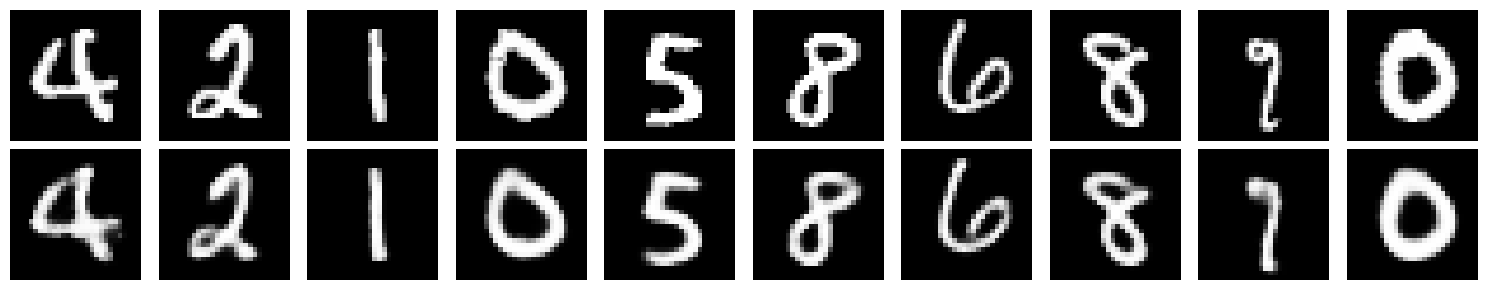

In [119]:
vae.eval()
with torch.no_grad():
    images, _ = next(iter(train_loader))
    images = images.to(device)        # move images to GPU
    recon, _, _ = vae(images)
    images = images.cpu()             # move back to CPU for plotting
    recon = recon.cpu()               # move back to CPU for plotting

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Reconstructed', fontsize=12)
plt.tight_layout()
plt.show()

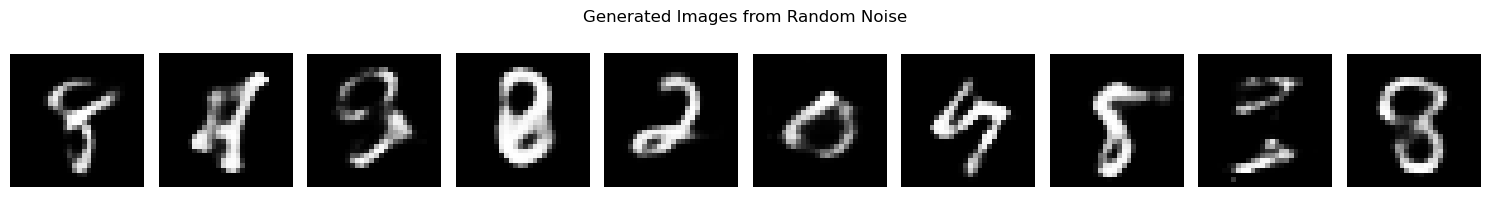

In [123]:
vae.eval()
with torch.no_grad():
    # sample random points in latent space
    z = torch.randn(10, 16).to(device)  # 10 random latent vectors
    generated = vae.decoder(z).cpu()

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(generated[i].squeeze(), cmap='gray')
    ax.axis('off')

plt.suptitle('Generated Images from Random Noise', fontsize=12)
plt.tight_layout()
plt.show()

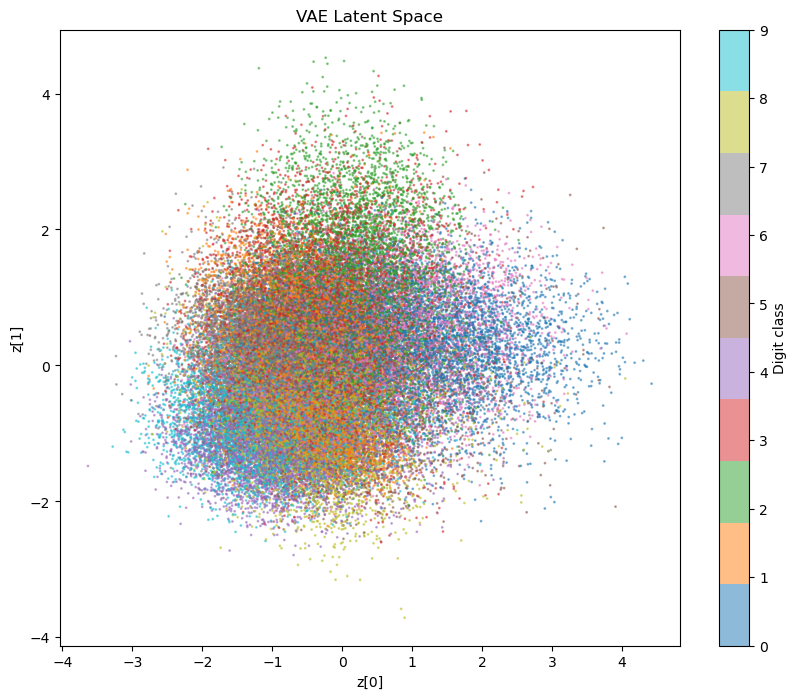

In [125]:
vae.eval()
all_z = []
all_labels = []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        mu, _ = vae.encoder(images)
        all_z.append(mu.cpu())
        all_labels.append(labels)

all_z = torch.cat(all_z).numpy()
all_labels = torch.cat(all_labels).numpy()

# reduce to 2D for visualization using first 2 latent dims
plt.figure(figsize=(10, 8))
scatter = plt.scatter(all_z[:, 0], all_z[:, 1], c=all_labels, cmap='tab10', alpha=0.5, s=1)
plt.colorbar(scatter, label='Digit class')
plt.title('VAE Latent Space')
plt.xlabel('z[0]')
plt.ylabel('z[1]')
plt.show()

In [127]:
torch.save(vae.state_dict(), 'vae_mnist.pth')
print("Model saved!")

Model saved!


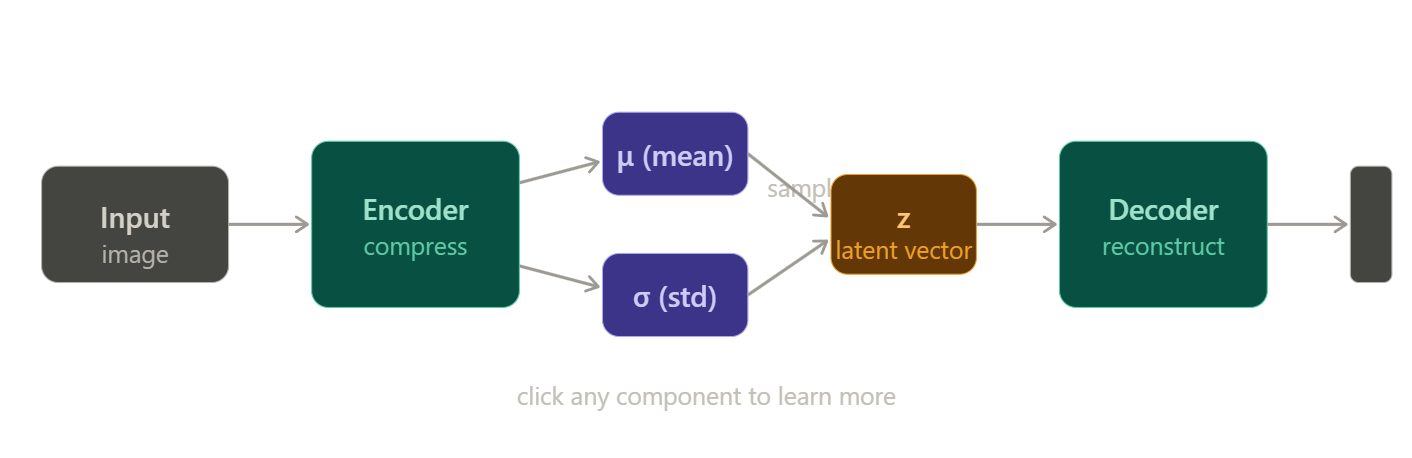